In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
# load data 
data = pd.read_csv(r'./data/NTS-NOTEARS/X.csv', header=None)
X_ = data.values
X = X_.T
print(X.shape)

A_ = pd.read_csv(r'./data/NTS-NOTEARS/W_true.csv', header=None)
A = A_.values

(5, 5000)


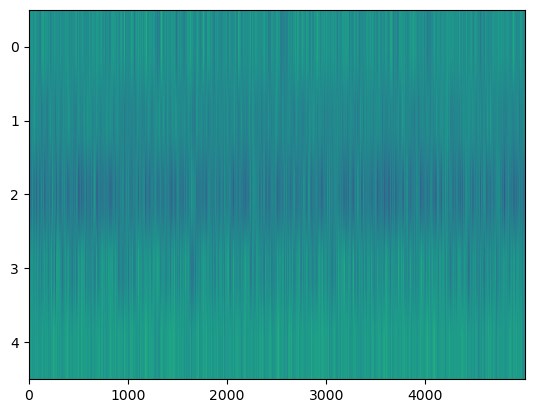

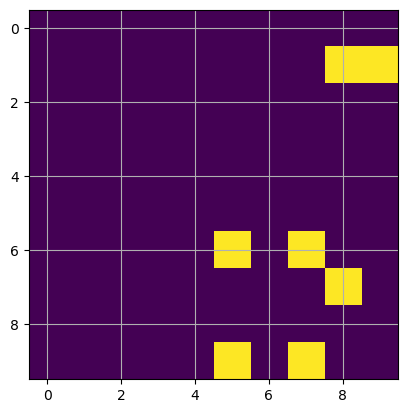

In [4]:
plt.figure()
plt.imshow(X, aspect='auto')

plt.figure()
plt.imshow(A!=0)
plt.grid()

12

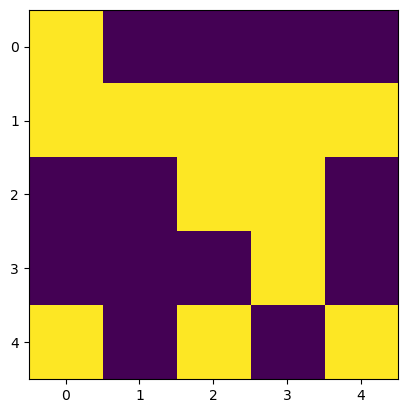

In [22]:
B = np.array([[1,0,0,0,0],
              [1,1,1,1,1],
              [0,0,1,1,0],
              [0,0,0,1,0],
              [1,0,1,0,1]])
plt.imshow(B)
aa = np.transpose(np.where(B!=0))
B_ = np.c_[aa,np.ones(len(aa))]
len(B_)
# np.savetxt('notears_gt.csv', B_, delimiter=',')

## Analysis

In [6]:
N_PASTS, n_lags, n_perm = np.arange(3, 6, 1), 2, 1000


3 pasts
4 pasts
5 pasts
CPU times: total: 3min 45s
Wall time: 52.1 s


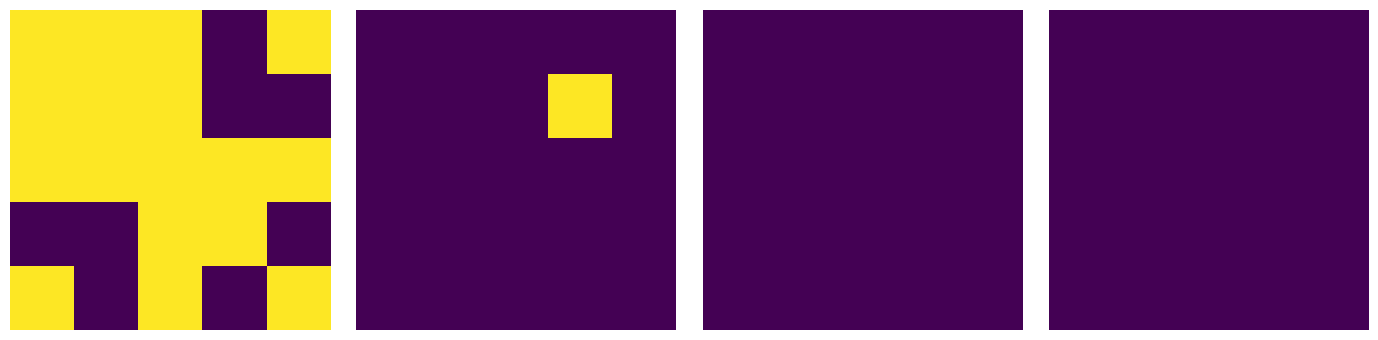

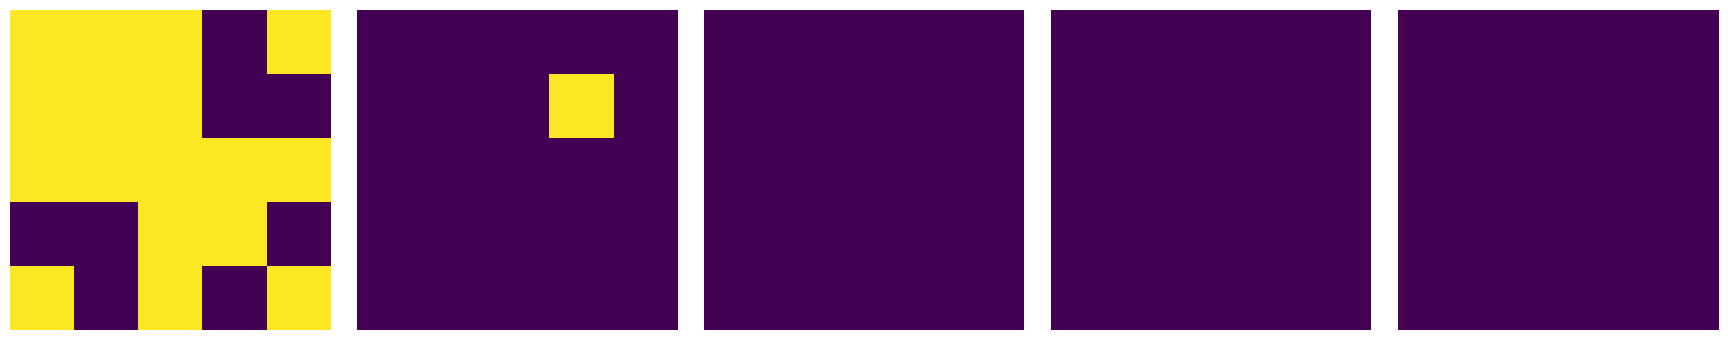

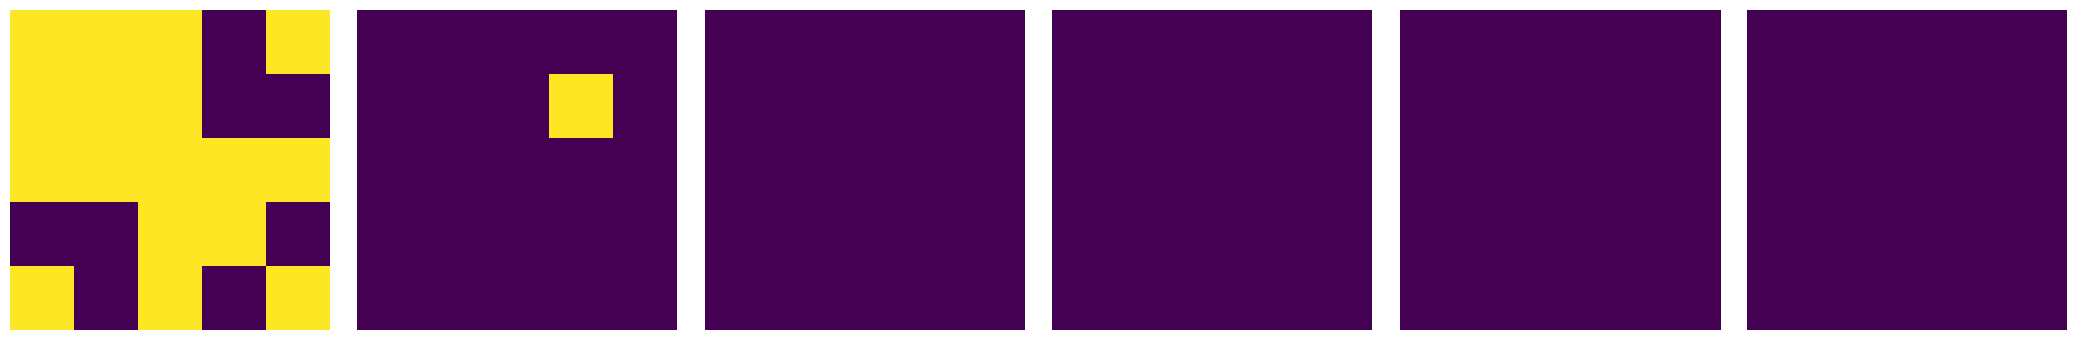

In [7]:
%%time
metrics = np.zeros((3,4))
infs = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'cgc')
    
    gcstar.fit(X, verbose = 0)
    
    infs.append(gcstar.get_connectivity_matrix(alpha=0, beta=0))   # simulation=False)
    gcstar.plot_extended_connectivity_matrix(alpha=0, beta=0)
    gcstar.compute_confusion_matrix(B)   #  simulation = False
    metrics[i] = gcstar.compute_metrics()

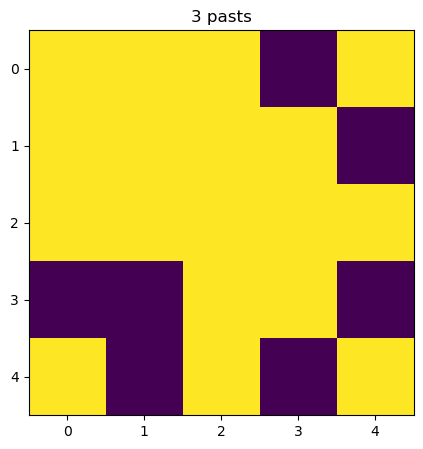

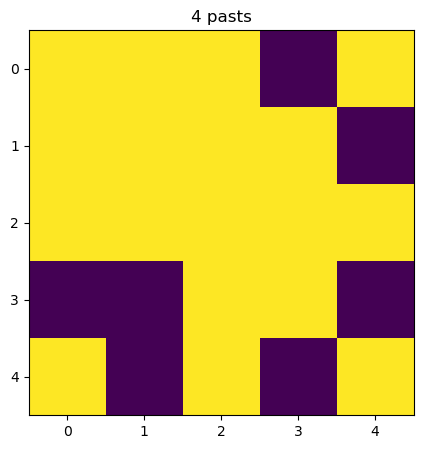

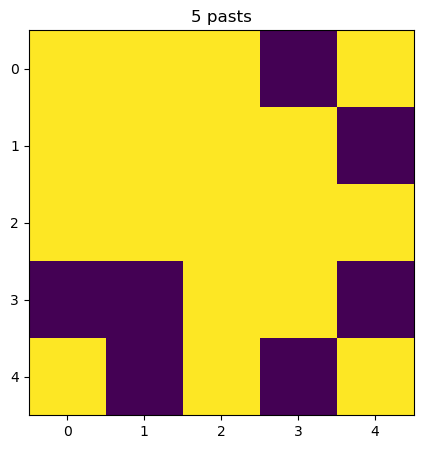

In [8]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(el!=0)
    plt.title(f'{i+3} pasts')

In [9]:
metrics

array([[0.68      , 0.61111111, 0.91666667, 0.53846154],
       [0.68      , 0.61111111, 0.91666667, 0.53846154],
       [0.68      , 0.61111111, 0.91666667, 0.53846154]])

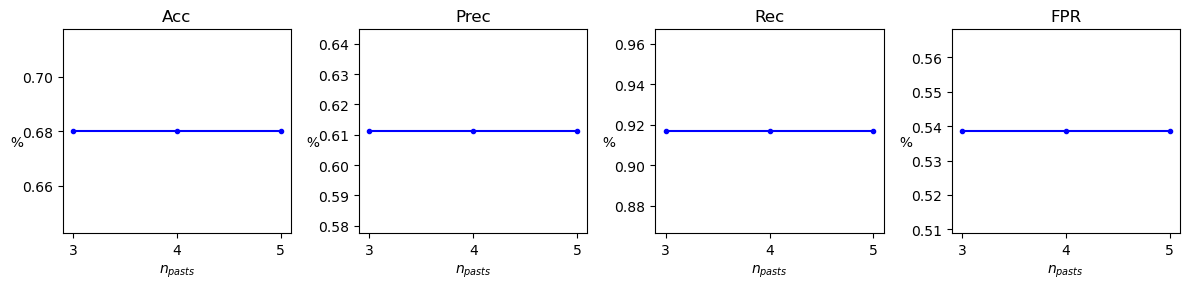

In [10]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(3, 6, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

In [11]:
def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)

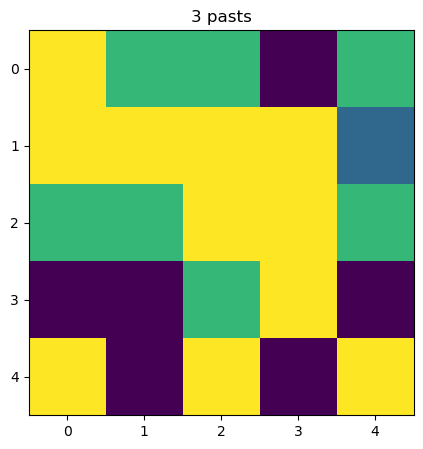

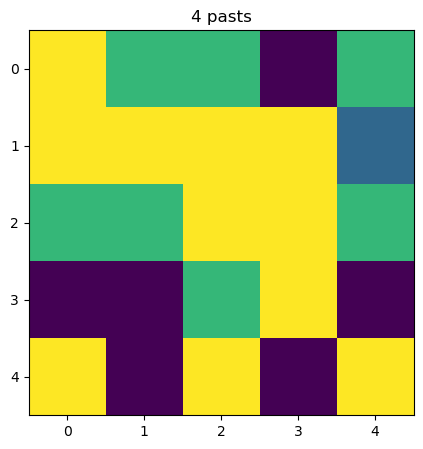

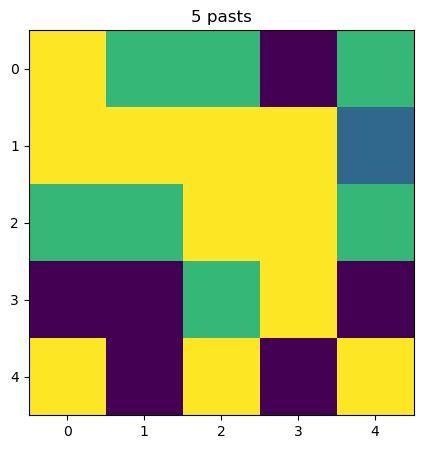

In [12]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(B, el))
    plt.title(f'{i+3} pasts')

In [13]:
i_ = np.array([[1,0,0,0,0],
              [1,1,1,1,0],
              [0,0,1,1,0],
              [0,0,0,1,0],
              [1,0,1,0,1]])

In [14]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FP_inf],
                     [FN_inf,TN_inf]])


def apr_metrics(confusion_matrix):
    confusion_matrix = confusion_matrix.flatten()
    accuracy = (confusion_matrix[0] + confusion_matrix[3])/(np.sum(confusion_matrix))
    precision = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[2])
    recall = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[1])
    FPR = confusion_matrix[2]/(confusion_matrix[2]+confusion_matrix[3])
    return np.array([accuracy, precision, recall, FPR])


In [27]:

apr_metrics(np.array([[7,2],[108,783]]))

array([0.87777778, 0.06086957, 0.77777778, 0.12121212])

In [17]:
import seaborn as sns